Version 2 of the api

In [21]:
import requests
import geopandas as gpd
import pandas as pd
import geopandas as gpd

In [22]:

API_KEY = "8b68afc74212495b418f65112132e1c5ea1d457982bc3737435ada832f03cfbb"

url = "https://api.openaq.org/v3/locations"

headers = {
    "X-API-Key": API_KEY
}

params = {
    "limit": 5
}

response = requests.get(url, headers=headers, params=params)

print(response.status_code)
print(response.json())

200
{'meta': {'name': 'openaq-api', 'website': '/', 'page': 1, 'limit': 5, 'found': '>5'}, 'results': [{'id': 3, 'name': 'NMA - Nima', 'locality': None, 'timezone': 'Africa/Accra', 'country': {'id': 152, 'code': 'GH', 'name': 'Ghana'}, 'owner': {'id': 4, 'name': 'Unknown Governmental Organization'}, 'provider': {'id': 209, 'name': 'Dr. Raphael E. Arku and Colleagues'}, 'isMobile': False, 'isMonitor': True, 'instruments': [{'id': 2, 'name': 'Government Monitor'}], 'sensors': [{'id': 6, 'name': 'pm10 µg/m³', 'parameter': {'id': 1, 'name': 'pm10', 'units': 'µg/m³', 'displayName': 'PM10'}}, {'id': 5, 'name': 'pm25 µg/m³', 'parameter': {'id': 2, 'name': 'pm25', 'units': 'µg/m³', 'displayName': 'PM2.5'}}], 'coordinates': {'latitude': 5.58389, 'longitude': -0.19968}, 'licenses': None, 'bounds': [-0.19968, 5.58389, -0.19968, 5.58389], 'distance': None, 'datetimeFirst': None, 'datetimeLast': None}, {'id': 4, 'name': 'NMT - Nima', 'locality': None, 'timezone': 'Africa/Accra', 'country': {'id': 1

The api request went through!!

The rest goal is to convert this to a geopandas df and then save the the df beofre moving onto the next part of the pipeline

I want to convert the aboce code into a function thatb also converts the api request into a pandas df

In [53]:
# Libraries needed for the function
import requests
import pandas as pd
import geopandas as gpd

def get_openaq_data(api_key, limit=1000):
    """
    Function to retrieve data from the OpenAQ API and convert it to a GeoDataFrame.
    
    Parameters:
     api_key: Your API key for authentication.
     limit: The number of records to retrieve (default is 100).
    
    returns: A GeoDataFrame containing the locations data from OpenAQ.
    """

    url = "https://api.openaq.org/v3/locations"

    headers = {
        "X-API-Key": api_key
    }

    params = {
        "limit": limit
    }

    response = requests.get(url, headers=headers, params=params)

    if response.status_code != 200:
        raise Exception(f"API request failed: {response.status_code}")

    data = response.json()

    # Convert JSON to dataframe
    df = pd.json_normalize(data["results"])

    # Convert to GeoDataFrame
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(
            df["coordinates.longitude"],
            df["coordinates.latitude"]
        ),
        crs="EPSG:4326"
    )

    return gdf

In [54]:
openaq_gdf = get_openaq_data(API_KEY, limit=1000)
print(openaq_gdf.head())

   id                 name locality      timezone  isMobile  isMonitor  \
0   3           NMA - Nima     None  Africa/Accra     False       True   
1   4           NMT - Nima     None  Africa/Accra     False       True   
2   5      JTA - Jamestown     None  Africa/Accra     False       True   
3   6    ADT - Asylum Down     None  Africa/Accra     False       True   
4   7  ADEPA - Asylum Down     None  Africa/Accra     False       True   

                                 instruments  \
0  [{'id': 2, 'name': 'Government Monitor'}]   
1  [{'id': 2, 'name': 'Government Monitor'}]   
2  [{'id': 2, 'name': 'Government Monitor'}]   
3  [{'id': 2, 'name': 'Government Monitor'}]   
4  [{'id': 2, 'name': 'Government Monitor'}]   

                                             sensors licenses  \
0  [{'id': 6, 'name': 'pm10 µg/m³', 'parameter': ...     None   
1  [{'id': 7, 'name': 'pm10 µg/m³', 'parameter': ...     None   
2  [{'id': 10, 'name': 'pm10 µg/m³', 'parameter':...     None   
3  [{'

The api request works and now I will. filter the df for the Regina data I need

In [55]:
# Look at the colimns so I can filter for Regina Saskatchewan Canada
print(openaq_gdf.columns)

Index(['id', 'name', 'locality', 'timezone', 'isMobile', 'isMonitor',
       'instruments', 'sensors', 'licenses', 'bounds', 'distance',
       'datetimeFirst', 'datetimeLast', 'country.id', 'country.code',
       'country.name', 'owner.id', 'owner.name', 'provider.id',
       'provider.name', 'coordinates.latitude', 'coordinates.longitude',
       'datetimeFirst.utc', 'datetimeFirst.local', 'datetimeLast.utc',
       'datetimeLast.local', 'geometry'],
      dtype='object')


In [63]:
print(openaq_gdf["country.code"].unique())

['GH' 'IN' 'AR' 'VN' 'MN' 'CN' 'BD' 'SG' 'CL' 'PL' 'NL' 'IL' 'NG' 'TH'
 'GB' 'US' 'CA' 'AU' 'MX' 'PR' 'BA' 'PE']


In [72]:
# print the canda locations
canada_locations = openaq_gdf[openaq_gdf["country.code"] == "CA"]
print(canada_locations.head(5))  



      id        name locality           timezone  isMobile  isMonitor  \
230  285     Wagner2  ALBERTA   America/Edmonton     False       True   
232  287    St. Lina  ALBERTA   America/Edmonton     False       True   
240  297     Steeper  ALBERTA   America/Edmonton     False       True   
241  298  Bruderheim  ALBERTA   America/Edmonton     False       True   
248  307    Squamish     None  America/Vancouver     False       True   

                                   instruments  \
230  [{'id': 2, 'name': 'Government Monitor'}]   
232  [{'id': 2, 'name': 'Government Monitor'}]   
240  [{'id': 2, 'name': 'Government Monitor'}]   
241  [{'id': 2, 'name': 'Government Monitor'}]   
248  [{'id': 2, 'name': 'Government Monitor'}]   

                                               sensors  \
230  [{'id': 473, 'name': 'no2 ppm', 'parameter': {...   
232  [{'id': 477, 'name': 'no2 ppm', 'parameter': {...   
240  [{'id': 498, 'name': 'no2 ppm', 'parameter': {...   
241  [{'id': 496, 'name': 'n

locality is the target column and it uses all caps, going to try and get sask

In [75]:
# Print locality == SASKATCHEWAN
saskatchewan_locations = openaq_gdf[openaq_gdf["locality"] == "SASKATCHEWAN"]

#print(saskatchewan_locations.head())  

#print(saskatchewan_locations.columns)

# look at station names
print(saskatchewan_locations["name"])

843    Saskatoon
Name: name, dtype: object


The dataset seems to only have saskatoon data, at least based of the locality and name column, I will use saskatoon instead of Regina for simplicity reasons. I may be able to get regina data afterwords.

In [78]:
saskatoon_gdf = openaq_gdf[
    (openaq_gdf["locality"] == "SASKATCHEWAN") &
    (openaq_gdf["name"].str.contains("Saskatoon", case=False, na=False))
]

print(saskatoon_gdf)

      id       name      locality        timezone  isMobile  isMonitor  \
843  958  Saskatoon  SASKATCHEWAN  America/Regina     False       True   

                                   instruments  \
843  [{'id': 2, 'name': 'Government Monitor'}]   

                                               sensors  \
843  [{'id': 5077666, 'name': 'no2 ppm', 'parameter...   

                                              licenses  \
843  [{'id': 33, 'name': 'US Public Domain', 'attri...   

                                               bounds  ...  \
843  [-106.662796, 52.136055, -106.662796, 52.136055]  ...   

                            owner.name  provider.id  provider.name  \
843  Unknown Governmental Organization          119         AirNow   

     coordinates.latitude coordinates.longitude     datetimeFirst.utc  \
843             52.136055           -106.662796  2016-03-06T20:00:00Z   

           datetimeFirst.local      datetimeLast.utc  \
843  2016-03-06T14:00:00-06:00  2026-04-12T18:0

I now have a df with all the sask data, now I need to narrow this down for regina

<Axes: >

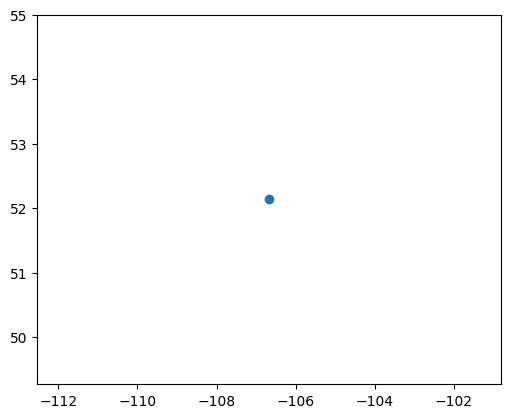

In [79]:
saskatoon_gdf.plot()

In [80]:
print(saskatoon_gdf["sensors"].iloc[0])

[{'id': 5077666, 'name': 'no2 ppm', 'parameter': {'id': 7, 'name': 'no2', 'units': 'ppm', 'displayName': 'NO₂'}}, {'id': 1744, 'name': 'o3 ppm', 'parameter': {'id': 10, 'name': 'o3', 'units': 'ppm', 'displayName': 'O₃'}}, {'id': 25720, 'name': 'pm25 µg/m³', 'parameter': {'id': 2, 'name': 'pm25', 'units': 'µg/m³', 'displayName': 'PM2.5'}}]


I have all the data I need to model the pollution around saskatoon

no2 ppm: 
    * Produced by vehicle exhaust and industrial combustion
	•	Common near traffic corridors and urban areas
	•	Important for human respiratory health

o3 ppm:
	* A secondary pollutant formed from sunlight reacting with other pollutants
	•	High in summer smog events
	•	Important for air quality advisories


PM2.5 (Fine Particulate Matter)
	•	smoke
	•	dust
	•	combustion particles
	•	wildfire pollution
